In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Đọc file (dùng ../ để lùi ra thư mục gốc rồi vào data/raw)
df = pd.read_csv('../data/raw/student_depression_dataset.csv')

# Kiểm tra tổng quan
print(f"Kích thước ban đầu: {df.shape[0]} dòng, {df.shape[1]} cột")
display(df.head())

# Lọc chỉ lấy đúng sinh viên
df = df[df['Profession'] == 'Student'].copy()
print(f"Số dòng sau khi lọc nhóm Student: {df.shape[0]}")

Kích thước ban đầu: 27901 dòng, 18 cột


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


Số dòng sau khi lọc nhóm Student: 27870


In [4]:
# Kiểm tra tỷ lệ missing
missing_pct = df.isnull().sum() / len(df) * 100
print("Tỷ lệ missing ban đầu:\n", missing_pct[missing_pct > 0])

# 1. Drop dòng nếu cột mục tiêu 'Depression' bị thiếu
df = df.dropna(subset=['Depression'])

# 2. Drop cột nếu missing > 50%
cols_to_drop = missing_pct[missing_pct > 50].index
df = df.drop(columns=cols_to_drop)

# 3. Điền giá trị thiếu (Fillna)
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Điền cột số bằng trung vị (median)
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Điền cột chữ bằng yếu tố xuất hiện nhiều nhất (mode)
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print(f"Tổng số ô missing sau xử lý: {df.isnull().sum().sum()} (Phải là 0 mới chuẩn)")

Tỷ lệ missing ban đầu:
 Series([], dtype: float64)
Tổng số ô missing sau xử lý: 0 (Phải là 0 mới chuẩn)


C:\Users\Admin\AppData\Local\Temp\ipykernel_28596\1113013342.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [5]:
# Xử lý text thừa khoảng trắng và sai hoa/thường
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.title()

# Lọc các giá trị vô lý (Giữ lại tuổi sinh viên hợp lý 15-35)
df = df[(df['Age'] >= 15) & (df['Age'] <= 35)]

# Đảm bảo cột target chuẩn int (0 và 1)
df['Depression'] = df['Depression'].astype(int)

print("Đã dọn dẹp format thành công!")

Đã dọn dẹp format thành công!


C:\Users\Admin\AppData\Local\Temp\ipykernel_28596\568086490.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Depression', palette='Set2')


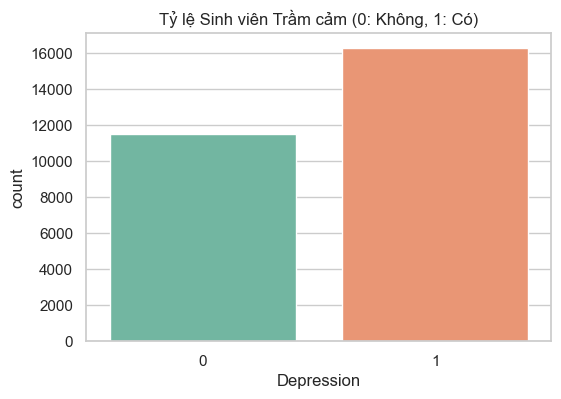

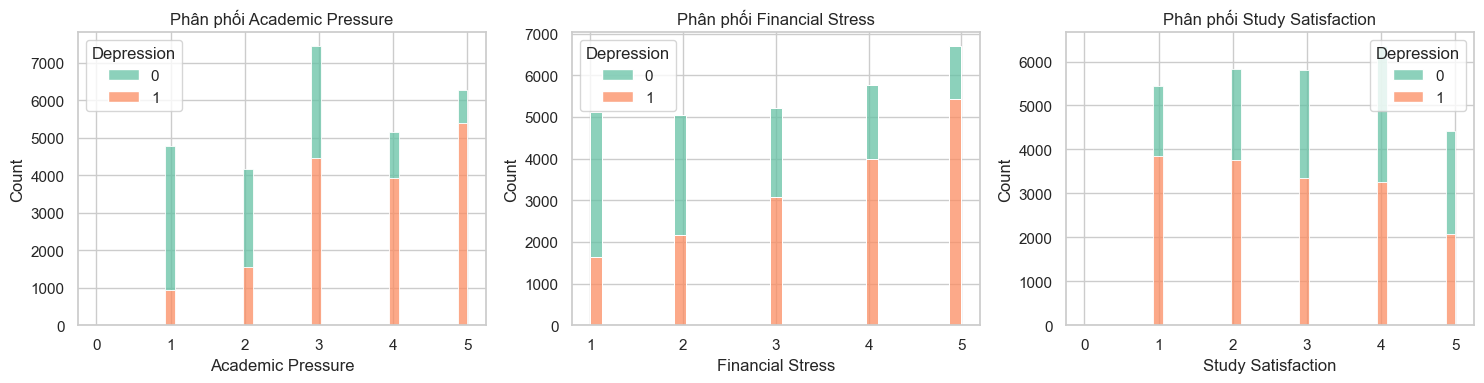

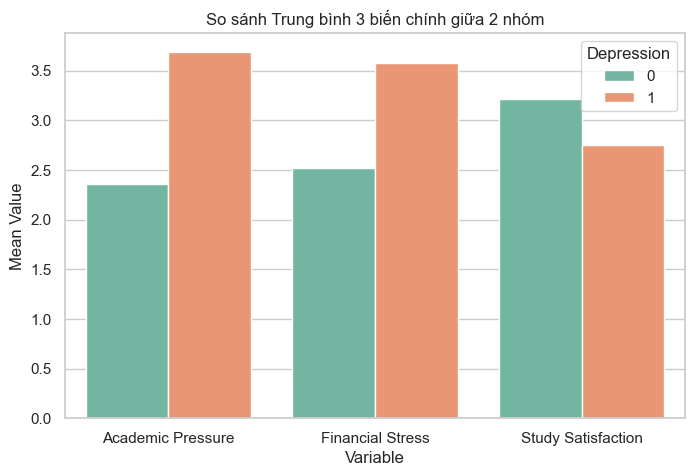

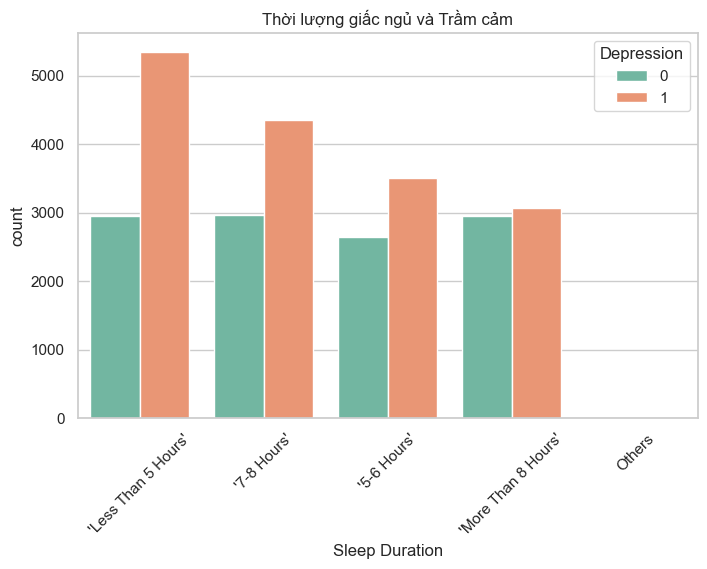

In [8]:
sns.set_theme(style="whitegrid")
main_vars = ['Academic Pressure', 'Financial Stress', 'Study Satisfaction']

# Ép 3 cột chính về chuẩn dữ liệu số (loại bỏ ký tự lạ như '?')
for col in main_vars:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

# 1. Bar chart tỷ lệ trầm cảm
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Depression', palette='Set2')
plt.title('Tỷ lệ Sinh viên Trầm cảm (0: Không, 1: Có)')
plt.savefig('../output/figures/1_depression_ratio.png', bbox_inches='tight')
plt.show()

# 2. Histogram 3 biến chính chia theo nhóm Target
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, var in enumerate(main_vars):
    sns.histplot(data=df, x=var, hue='Depression', multiple="stack", ax=axes[i], palette='Set2')
    axes[i].set_title(f'Phân phối {var}')
plt.tight_layout()
plt.savefig('../output/figures/2_histograms.png', bbox_inches='tight')
plt.show()

# 3. Bar chart so sánh Mean của 3 biến
mean_df = df.groupby('Depression')[main_vars].mean().reset_index()
mean_melted = pd.melt(mean_df, id_vars='Depression', var_name='Variable', value_name='Mean Value')

plt.figure(figsize=(8, 5))
sns.barplot(data=mean_melted, x='Variable', y='Mean Value', hue='Depression', palette='Set2')
plt.title('So sánh Trung bình 3 biến chính giữa 2 nhóm')
plt.savefig('../output/figures/3_mean_comparison.png', bbox_inches='tight')
plt.show()

# 4. Biểu đồ Categorical (Giấc ngủ vs Trầm cảm)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Sleep Duration', hue='Depression', palette='Set2', 
              order=df['Sleep Duration'].value_counts().index)
plt.title('Thời lượng giấc ngủ và Trầm cảm')
plt.xticks(rotation=45)
plt.savefig('../output/figures/4_sleep_depression.png', bbox_inches='tight')
plt.show()

In [10]:
# Xuất file CSV sạch
clean_path = '../data/clean/student_depression_clean.csv'
df.to_csv(clean_path, index=False)
print(f"XONG! Đã lưu file sạch với {df.shape[0]} dòng và {df.shape[1]} cột.")

XONG! Đã lưu file sạch với 27831 dòng và 18 cột.
